# RTMPose-X + GSTCAN — Local Video/Label Notebook

Run cells from top to bottom. This version is for a local PC/Jupyter notebook. It does **not** download or extract a dataset and does **not** use Google Drive.

Expected layout:
```text
D:/YourDataset/Videos/
    video_001.mp4
    video_002.avi
    ...

D:/YourDataset/Labels/
    video_001.txt   # contains 0 or 1
    video_002.txt   # contains 0 or 1
    ...
```

Each label filename must have the same stem as its video. All generated data are saved under `RESULTS_DIR`.

In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import sys
import rtmlib
import onnxruntime as ort

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("ONNX Runtime:", ort.__version__)
print("Providers:", ort.get_available_providers())
print("RTMLib:", rtmlib.__file__)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python executable: c:\Users\PEGASUS\AppData\Local\Programs\Python\Python312\python.exe
ONNX Runtime: 1.26.0
Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
RTMLib: c:\Users\PEGASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\rtmlib\__init__.py


## CELL 1 — INSTALL FINAL LOCAL ENVIRONMENT

## CELL 2 — VERIFY ENVIRONMENT

In [3]:
import sys
import torch
import cv2
import numpy as np
import onnxruntime as ort

print("Python       :", sys.version)
print("PyTorch      :", torch.__version__)
print("PyTorch CUDA :", torch.version.cuda)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

print("\nOpenCV       :", cv2.__version__)
print("ONNX Runtime :", ort.__version__)
print("\nONNX Runtime providers:")
print(ort.get_available_providers())

assert torch.cuda.is_available(), "CUDA is not available."
assert "CUDAExecutionProvider" in ort.get_available_providers(), \
    "CUDAExecutionProvider is not available."
assert ort.__version__ == "1.26.0", \
    f"Expected ONNX Runtime 1.26.0, got {ort.__version__}"

from rtmlib import Body
print("\nrtmlib import: OK")
print("Environment verification PASSED.")

Python       : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch      : 2.11.0+cu128
PyTorch CUDA : 12.8
CUDA         : True
GPU          : NVIDIA GeForce RTX 3070 Ti

OpenCV       : 5.0.0
ONNX Runtime : 1.26.0

ONNX Runtime providers:
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

rtmlib import: OK
Environment verification PASSED.


## CELL 3 — LOCAL DATASET PATHS AND RESULTS FOLDERS

In [4]:
from pathlib import Path

# ============================================================
# CHANGE ONLY THESE THREE PATHS
# ============================================================
VIDEO_DIR = Path(r"D:\Le2i\Videos")
LABEL_DIR = Path(r"D:\Le2i\Annotation_files")
RESULTS_DIR = Path(r"D:\Le2i\Results\RTM-PoseX Results")

# ============================================================
# Supported video extensions
# ============================================================
VIDEO_EXTENSIONS = {
    ".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".wmv", ".m4v"
}

PROCESSED_DIR = RESULTS_DIR / "processed"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
PLOTS_DIR = RESULTS_DIR / "plots"
METRICS_DIR = RESULTS_DIR / "metrics"

for directory in [RESULTS_DIR, PROCESSED_DIR, CHECKPOINT_DIR, PLOTS_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("VIDEO_DIR    :", VIDEO_DIR)
print("LABEL_DIR    :", LABEL_DIR)
print("RESULTS_DIR  :", RESULTS_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("CHECKPOINTS  :", CHECKPOINT_DIR)
print("PLOTS_DIR    :", PLOTS_DIR)
print("METRICS_DIR  :", METRICS_DIR)

assert VIDEO_DIR.exists(), f"Video folder does not exist: {VIDEO_DIR}"
assert LABEL_DIR.exists(), f"Label folder does not exist: {LABEL_DIR}"

VIDEO_DIR    : D:\Le2i\Videos
LABEL_DIR    : D:\Le2i\Annotation_files
RESULTS_DIR  : D:\Le2i\Results\RTM-PoseX Results
PROCESSED_DIR: D:\Le2i\Results\RTM-PoseX Results\processed
CHECKPOINTS  : D:\Le2i\Results\RTM-PoseX Results\checkpoints
PLOTS_DIR    : D:\Le2i\Results\RTM-PoseX Results\plots
METRICS_DIR  : D:\Le2i\Results\RTM-PoseX Results\metrics


## CELL 4 — DISCOVER VIDEOS AND SAME-NAME TXT LABELS

In [5]:
import re
from pathlib import Path


def read_binary_label(label_path: Path) -> int:
    text = label_path.read_text(encoding="utf-8", errors="ignore").strip()
    if text not in {"0", "1"}:
        # Accept a first token such as "1 # fall" only if the first token is exactly 0/1.
        token = text.split()[0] if text.split() else ""
        if token not in {"0", "1"}:
            raise ValueError(f"Label file must contain 0 or 1: {label_path}; got {text!r}")
        text = token
    return int(text)


def discover_video_label_pairs(video_dir: Path, label_dir: Path):
    videos = {}
    for path in video_dir.iterdir():
        if path.is_file() and path.suffix.lower() in VIDEO_EXTENSIONS:
            key = path.stem.lower()
            if key in videos:
                raise RuntimeError(f"Duplicate video stem: {path.stem}")
            videos[key] = path

    labels = {}
    for path in label_dir.glob("*.txt"):
        key = path.stem.lower()
        if key in labels:
            raise RuntimeError(f"Duplicate label stem: {path.stem}")
        labels[key] = path

    video_only = sorted(set(videos) - set(labels))
    label_only = sorted(set(labels) - set(videos))

    if video_only:
        raise RuntimeError(f"Videos without matching labels ({len(video_only)}): {video_only[:10]}")
    if label_only:
        raise RuntimeError(f"Labels without matching videos ({len(label_only)}): {label_only[:10]}")

    records = []
    for key in sorted(videos):
        records.append({
            "name": videos[key].stem,
            "video": videos[key],
            "label_file": labels[key],
            "label": read_binary_label(labels[key]),
        })

    return records

records = discover_video_label_pairs(VIDEO_DIR, LABEL_DIR)

print("Matched video/label pairs:", len(records))
print("Fall:", sum(r["label"] == 1 for r in records))
print("ADL :", sum(r["label"] == 0 for r in records))

assert len(records) > 0, "No video/label pairs found."
assert all(r["label"] in {0, 1} for r in records)

print("\nFirst records:")
for record in records[:10]:
    print(record["name"], "label=", record["label"], "video=", record["video"].name)

Matched video/label pairs: 190
Fall: 130
ADL : 60

First records:
video (1) label= 1 video= video (1).avi
video (10) label= 1 video= video (10).avi
video (100) label= 1 video= video (100).avi
video (101) label= 1 video= video (101).avi
video (102) label= 1 video= video (102).avi
video (103) label= 1 video= video (103).avi
video (104) label= 1 video= video (104).avi
video (105) label= 1 video= video (105).avi
video (106) label= 1 video= video (106).avi
video (107) label= 1 video= video (107).avi


## CELL 5 — CREATE RTMPOSE-X

In [6]:
#cell 5

from rtmlib import Body

DEVICE = "cuda"
BACKEND = "onnxruntime"

pose_model = Body(
    det=(
        "https://download.openmmlab.com/"
        "mmpose/v1/projects/rtmposev1/onnx_sdk/"
        "yolox_x_8xb8-300e_humanart-a39d44ed.zip"
    ),
    det_input_size=(640, 640),
    pose=(
        "https://download.openmmlab.com/"
        "mmpose/v1/projects/rtmposev1/onnx_sdk/"
        "rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.zip"
    ),
    pose_input_size=(288, 384),
    backend=BACKEND,
    device=DEVICE,
    to_openpose=False,
)

print("RTMPose-X Body model created.")

load C:\Users\PEGASUS\.cache\rtmlib\hub\checkpoints\yolox_x_8xb8-300e_humanart-a39d44ed.onnx with onnxruntime backend
load C:\Users\PEGASUS\.cache\rtmlib\hub\checkpoints\rtmpose-x_simcc-body7_pt-body7_700e-384x288-71d7b7e9_20230629.onnx with onnxruntime backend
RTMPose-X Body model created.


## CELL 6 — VERIFY RTMPOSE-X PROVIDERS

In [7]:
#Cell 6

det_providers = pose_model.det_model.session.get_providers()
pose_providers = pose_model.pose_model.session.get_providers()

print("YOLOX providers:")
print(det_providers)
print("\nRTMPose providers:")
print(pose_providers)

assert "CUDAExecutionProvider" in det_providers, \
    "YOLOX is not using CUDAExecutionProvider."
assert "CUDAExecutionProvider" in pose_providers, \
    "RTMPose is not using CUDAExecutionProvider."

print("\nRTMPose-X is configured for CUDA.")

YOLOX providers:
['CUDAExecutionProvider', 'CPUExecutionProvider']

RTMPose providers:
['CUDAExecutionProvider', 'CPUExecutionProvider']

RTMPose-X is configured for CUDA.


## CELL 7 — GSTCAN 13-JOINT DEFINITION

In [8]:
#Cell 7

import numpy as np

# RTMPose-X COCO-17 indices:
# 0 nose, 1 left_eye, 2 right_eye, 3 left_ear, 4 right_ear,
# 5 left_shoulder, 6 right_shoulder, 7 left_elbow, 8 right_elbow,
# 9 left_wrist, 10 right_wrist, 11 left_hip, 12 right_hip,
# 13 left_knee, 14 right_knee, 15 left_ankle, 16 right_ankle.

JOINT_NAMES = [
    "neck",
    "left_shoulder", "left_elbow", "left_wrist",
    "right_shoulder", "right_elbow", "right_wrist",
    "left_hip", "left_knee", "left_ankle",
    "right_hip", "right_knee", "right_ankle",
]

# GSTCAN joints 1..12 are direct COCO-17 joints.
COCO_TO_GSTCAN = np.array([
    5, 7, 9,
    6, 8, 10,
    11, 13, 15,
    12, 14, 16,
], dtype=np.int64)

# Neck = midpoint of both shoulders.
EDGES_13 = [
    (0, 1), (1, 2), (2, 3),
    (0, 4), (4, 5), (5, 6),
    (0, 7), (7, 8), (8, 9),
    (0, 10), (10, 11), (11, 12),
    (1, 7), (4, 10),
]

print("Joint count:", len(JOINT_NAMES))
print("Edges       :", len(EDGES_13))
for i, name in enumerate(JOINT_NAMES):
    print(f"{i:2d}: {name}")

assert len(JOINT_NAMES) == 13
assert len(COCO_TO_GSTCAN) == 12
assert len(EDGES_13) == 14

Joint count: 13
Edges       : 14
 0: neck
 1: left_shoulder
 2: left_elbow
 3: left_wrist
 4: right_shoulder
 5: right_elbow
 6: right_wrist
 7: left_hip
 8: left_knee
 9: left_ankle
10: right_hip
11: right_knee
12: right_ankle


## CELL 8 — RTMPOSE-X → GSTCAN 13-JOINT CONVERSION

In [9]:
# Cell 8


POSE_CONF_THRESHOLD = 0.20


def empty_pose():
    points13 = np.full((13, 2), np.nan, dtype=np.float32)
    scores13 = np.zeros(13, dtype=np.float32)
    return points13, scores13


def coco17_to_gstcan13(coco_keypoints, coco_scores):
    coco_keypoints = np.asarray(coco_keypoints, dtype=np.float32)
    coco_scores = np.asarray(coco_scores, dtype=np.float32)

    if coco_keypoints.shape != (17, 2):
        raise ValueError(f"Expected [17,2] keypoints, got {coco_keypoints.shape}")
    if coco_scores.shape != (17,):
        raise ValueError(f"Expected [17] scores, got {coco_scores.shape}")

    points13 = np.full((13, 2), np.nan, dtype=np.float32)
    scores13 = np.zeros(13, dtype=np.float32)

    points13[1:] = coco_keypoints[COCO_TO_GSTCAN]
    scores13[1:] = coco_scores[COCO_TO_GSTCAN]

    left_shoulder = coco_keypoints[5]
    right_shoulder = coco_keypoints[6]
    left_score = float(coco_scores[5])
    right_score = float(coco_scores[6])

    if (
        np.isfinite(left_shoulder).all()
        and np.isfinite(right_shoulder).all()
        and left_score >= POSE_CONF_THRESHOLD
        and right_score >= POSE_CONF_THRESHOLD
    ):
        points13[0] = (left_shoulder + right_shoulder) / 2.0
        scores13[0] = min(left_score, right_score)

    invalid = scores13 < POSE_CONF_THRESHOLD
    points13[invalid] = np.nan
    scores13[invalid] = 0.0
    return points13, scores13


def has_usable_skeleton(points13, scores13):
    valid = (
        np.isfinite(points13).all(axis=1)
        & (scores13 >= POSE_CONF_THRESHOLD)
    )
    return bool(np.all(valid))

print("Pose threshold:", POSE_CONF_THRESHOLD)

Pose threshold: 0.2


## CELL 9 — TEST RTMPOSE-X ON ONE LOCAL VIDEO FRAME

In [ ]:
# ============================================================
# CELL 9 — CHECK A SPECIFIC VIDEO + FRAME
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CHANGE ONLY THESE TWO VALUES
# ============================================================

VIDEO_NUMBER = 0       # Video number in records[]
FRAME_NUMBER = 7    # Frame number to inspect (0-based)

# ============================================================
# SETTINGS
# ============================================================

PERSON_SCORE_THRESHOLD = 0.30

# ============================================================
# SELECT VIDEO
# ============================================================

assert 0 <= VIDEO_NUMBER < len(records), (
    f"VIDEO_NUMBER must be between 0 and {len(records)-1}"
)

sample_video = records[VIDEO_NUMBER]["video"]

print("Video number :", VIDEO_NUMBER)
print("Video name   :", sample_video.name)
print("Label        :", records[VIDEO_NUMBER]["label"])
print("Frame number :", FRAME_NUMBER)

# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(str(sample_video))

assert cap.isOpened(), (
    f"Could not open video: {sample_video}"
)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(cv2.CAP_PROP_FPS)

print("Total frames :", total_frames)
print("FPS          :", fps)

assert 0 <= FRAME_NUMBER < total_frames, (
    f"FRAME_NUMBER must be between 0 and {total_frames - 1}"
)

# ============================================================
# JUMP DIRECTLY TO REQUESTED FRAME
# ============================================================

cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    FRAME_NUMBER
)

success, image = cap.read()

cap.release()

assert success and image is not None, (
    f"Could not read frame {FRAME_NUMBER}"
)

print("Frame shape  :", image.shape)

# ============================================================
# STEP 1 — YOLOX PERSON DETECTION
# ============================================================

det_model = pose_model.det_model

original_threshold = det_model.score_thr

det_model.score_thr = PERSON_SCORE_THRESHOLD

detections = det_model(image)

det_model.score_thr = original_threshold

detections = np.asarray(detections)

print("\nYOLOX detection result")
print("----------------------")
print("Shape:", detections.shape)
print("Detections:")
print(detections)

# ============================================================
# STEP 2 — DISPLAY FRAME
# ============================================================

vis = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.axis("off")

plt.title(
    f"Video {VIDEO_NUMBER} — "
    f"{sample_video.name} — "
    f"Frame {FRAME_NUMBER}"
)

plt.show()

# ============================================================
# STEP 3 — NO PERSON DETECTED
# ============================================================

if detections.size == 0:

    print("\n❌ NO PERSON DETECTED.")
    print("RTMPose will NOT be executed.")
    print("This frame should be discarded.")

    points13 = None
    scores13 = None

# ============================================================
# STEP 4 — PERSON DETECTED
# ============================================================

else:

    print("\n✅ PERSON DETECTED.")

    # --------------------------------------------------------
    # Run RTMPose
    # --------------------------------------------------------

    keypoints, scores = pose_model(image)

    keypoints = np.asarray(keypoints)
    scores = np.asarray(scores)

    print("\nRTMPose output")
    print("--------------")
    print("Keypoints:", keypoints.shape)
    print("Scores   :", scores.shape)

    if keypoints.shape[0] == 0:

        print("❌ RTMPose returned no pose.")

        points13 = None
        scores13 = None

    else:

        # ----------------------------------------------------
        # Select strongest person
        # ----------------------------------------------------

        person_confidence = np.mean(
            scores,
            axis=1
        )

        person_id = int(
            np.argmax(person_confidence)
        )

        best_confidence = float(
            person_confidence[person_id]
        )

        print(
            "\nSelected person:",
            person_id
        )

        print(
            "Mean pose confidence:",
            best_confidence
        )

        # ----------------------------------------------------
        # COCO-17 → GSTCAN-13
        # ----------------------------------------------------

        points13, scores13 = coco17_to_gstcan13(
            keypoints[person_id],
            scores[person_id],
        )

        usable = has_usable_skeleton(
            points13,
            scores13
        )

        print(
            "13-joint skeleton usable:",
            usable
        )

        # ----------------------------------------------------
        # Print joints
        # ----------------------------------------------------

        for i, name in enumerate(JOINT_NAMES):

            print(
                f"{i:2d} "
                f"{name:16s} "
                f"x={points13[i,0]:8.2f} "
                f"y={points13[i,1]:8.2f} "
                f"score={scores13[i]:.4f}"
            )

        # ----------------------------------------------------
        # Visualize skeleton
        # ----------------------------------------------------

        if usable:

            plt.figure(figsize=(12, 8))
            plt.imshow(vis)

            # Draw edges
            for a, b in EDGES_13:

                if (
                    np.isfinite(points13[a]).all()
                    and np.isfinite(points13[b]).all()
                    and scores13[a] >= POSE_CONF_THRESHOLD
                    and scores13[b] >= POSE_CONF_THRESHOLD
                ):

                    plt.plot(
                        [
                            points13[a, 0],
                            points13[b, 0]
                        ],
                        [
                            points13[a, 1],
                            points13[b, 1]
                        ],
                        linewidth=3,
                    )

            # Draw joints
            for i, name in enumerate(JOINT_NAMES):

                x, y = points13[i]

                if (
                    not np.isfinite([x, y]).all()
                    or scores13[i] < POSE_CONF_THRESHOLD
                ):
                    continue

                plt.scatter(
                    x,
                    y,
                    s=90
                )

                plt.text(
                    x + 5,
                    y + 5,
                    f"{i}:{name}",
                    fontsize=8,
                    fontweight="bold",
                )

            plt.xlim(
                0,
                image.shape[1]
            )

            plt.ylim(
                image.shape[0],
                0
            )

            plt.axis("off")

            plt.title(
                f"Video {VIDEO_NUMBER} — "
                f"Frame {FRAME_NUMBER} — "
                f"RTMPose-X → GSTCAN 13-Joint Skeleton"
            )

            plt.show()

        else:

            print(
                "\n❌ Skeleton rejected because "
                "not all 13 joints passed the threshold."
            )

## CELL 10 — VISUALIZE 13-JOINT EXTRACTION

In [ ]:
# ============================================================
# CELL 10 — FIND FIRST FRAME CONTAINING A PERSON
# ============================================================

# ============================================================
# CHANGE THIS
# ============================================================

VIDEO_NUMBER = 1

# ============================================================
# SETTINGS
# ============================================================

PERSON_SCORE_THRESHOLD = 0.30

# ============================================================
# SELECT VIDEO
# ============================================================

assert 0 <= VIDEO_NUMBER < len(records), (
    f"VIDEO_NUMBER must be between 0 and {len(records)-1}"
)

sample_video = records[VIDEO_NUMBER]["video"]

print("Video number :", VIDEO_NUMBER)
print("Video name   :", sample_video.name)
print("Label        :", records[VIDEO_NUMBER]["label"])

# ============================================================
# OPEN VIDEO
# ============================================================

cap = cv2.VideoCapture(str(sample_video))

assert cap.isOpened(), (
    f"Could not open video: {sample_video}"
)

total_frames = int(
    cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = cap.get(cv2.CAP_PROP_FPS)

print("Total frames :", total_frames)
print("FPS          :", fps)

# ============================================================
# YOLOX SETTINGS
# ============================================================

det_model = pose_model.det_model

original_threshold = det_model.score_thr
det_model.score_thr = PERSON_SCORE_THRESHOLD

# ============================================================
# SEARCH FRAME-BY-FRAME
# ============================================================

frame_index = 0
found = False

while True:

    success, frame = cap.read()

    if not success:
        break

    detections = det_model(frame)

    detections = np.asarray(detections)

    if detections.size > 0:

        print("\n========================================")
        print("PERSON FOUND")
        print("========================================")

        print("Frame index     :", frame_index)
        print("Detection shape :", detections.shape)
        print("Detections      :")
        print(detections)

        person_frame = frame.copy()
        person_frame_index = frame_index
        person_detections = detections.copy()

        found = True

        break

    frame_index += 1

# ============================================================
# RESTORE DETECTOR THRESHOLD
# ============================================================

det_model.score_thr = original_threshold

cap.release()

# ============================================================
# RESULT
# ============================================================

if not found:

    print("\n========================================")
    print("NO PERSON FOUND")
    print("========================================")

    print(
        f"No person was detected in any of the "
        f"{total_frames} frames."
    )

else:

    print(
        f"\nFirst detected person is at frame "
        f"{person_frame_index}"
    )

    print(
        f"Time: {person_frame_index / fps:.2f} seconds"
    )

    # --------------------------------------------------------
    # Display frame
    # --------------------------------------------------------

    plt.figure(figsize=(12, 8))

    plt.imshow(
        cv2.cvtColor(
            person_frame,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

    plt.title(
        f"Video {VIDEO_NUMBER} — "
        f"First detected person — "
        f"Frame {person_frame_index}"
    )

    plt.show()

## CELL 11 — EXTRACT SKELETONS DIRECTLY FROM LOCAL VIDEOS

In [ ]:
# ============================================================
# CELL 11 — EXTRACT VALID SKELETON SEQUENCES FROM ALL VIDEOS
# ============================================================

import pickle
import time
from tqdm.auto import tqdm


# ============================================================
# SETTINGS
# ============================================================

PERSON_SCORE_THRESHOLD = 0.30

# ------------------------------------------------------------
# IMPORTANT:
#
# Set this to True the FIRST time you run the corrected
# extraction, because old .pkl files may have been generated
# using the previous unsafe pose-only pipeline.
#
# After the corrected files exist, you can change this to False
# to use checkpoint skipping again.
# ------------------------------------------------------------

FORCE_REEXTRACT = False


def extract_video_sequence(record):

    sequence_name = record["name"]

    video_path = Path(record["video"])

    output_file = (
        PROCESSED_DIR /
        f"{sequence_name}.pkl"
    )

    # ========================================================
    # CHECKPOINT
    # ========================================================

    if output_file.exists() and not FORCE_REEXTRACT:

        print(
            f"SKIP {sequence_name}: "
            f"checkpoint already exists."
        )

        return

    # ========================================================
    # OPEN VIDEO
    # ========================================================

    cap = cv2.VideoCapture(
        str(video_path)
    )

    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    reported_frame_count = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    fps = float(
        cap.get(cv2.CAP_PROP_FPS)
    )

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    # ========================================================
    # STORAGE
    # ========================================================

    kept_skeletons = []
    kept_scores = []
    kept_frame_indices = []
    kept_frame_shapes = []

    # ========================================================
    # COUNTERS
    # ========================================================

    decoded_count = 0

    discarded_count = 0

    detector_miss_count = 0

    pose_error_count = 0

    invalid_skeleton_count = 0

    # ========================================================
    # TIMER
    # ========================================================

    start_time = time.perf_counter()

    pbar = tqdm(
        total=max(reported_frame_count, 0),
        desc=sequence_name,
        unit="frame"
    )

    # ========================================================
    # SAVE ORIGINAL DETECTOR THRESHOLD
    # ========================================================

    det_model = pose_model.det_model

    original_detector_threshold = (
        det_model.score_thr
    )

    det_model.score_thr = (
        PERSON_SCORE_THRESHOLD
    )

    # ========================================================
    # PROCESS VIDEO
    # ========================================================

    try:

        while True:

            success, frame = cap.read()

            if not success:
                break

            frame_index = decoded_count

            decoded_count += 1

            # =================================================
            # STEP 1 — PERSON DETECTION
            # =================================================

            try:

                detections = det_model(frame)

                detections = np.asarray(
                    detections
                )

            except Exception:

                pose_error_count += 1

                pbar.update(1)

                continue

            # =================================================
            # NO PERSON DETECTED
            # =================================================

            if detections.size == 0:

                detector_miss_count += 1

                discarded_count += 1

                pbar.update(1)

                continue

            # =================================================
            # STEP 2 — RUN RTMPOSE
            #
            # Only happens if YOLOX found a person.
            # =================================================

            try:

                keypoints, scores = pose_model(
                    frame
                )

                keypoints = np.asarray(
                    keypoints
                )

                scores = np.asarray(
                    scores
                )

            except Exception:

                pose_error_count += 1

                pbar.update(1)

                continue

            # =================================================
            # RTMPOSE FOUND NOTHING
            # =================================================

            if keypoints.shape[0] == 0:

                discarded_count += 1

                pbar.update(1)

                continue

            # =================================================
            # STEP 3 — SELECT STRONGEST PERSON
            # =================================================

            if scores.ndim != 2:

                pose_error_count += 1

                pbar.update(1)

                continue

            person_id = int(
                np.argmax(
                    np.mean(
                        scores,
                        axis=1
                    )
                )
            )

            # =================================================
            # STEP 4 — COCO-17 → GSTCAN-13
            # =================================================

            try:

                points13, scores13 = (
                    coco17_to_gstcan13(
                        keypoints[person_id],
                        scores[person_id],
                    )
                )

            except Exception:

                pose_error_count += 1

                pbar.update(1)

                continue

            # =================================================
            # STEP 5 — VALIDATE 13-JOINT SKELETON
            # =================================================

            if not has_usable_skeleton(
                points13,
                scores13
            ):

                invalid_skeleton_count += 1

                discarded_count += 1

                pbar.update(1)

                continue

            # =================================================
            # STEP 6 — KEEP VALID SKELETON
            # =================================================

            kept_skeletons.append(
                points13
            )

            kept_scores.append(
                scores13
            )

            kept_frame_indices.append(
                frame_index
            )

            kept_frame_shapes.append(
                (
                    frame.shape[1],
                    frame.shape[0]
                )
            )

            pbar.update(1)

    finally:

        cap.release()

        # Restore detector setting
        det_model.score_thr = (
            original_detector_threshold
        )

        pbar.close()

    # ========================================================
    # CONVERT TO NUMPY ARRAYS
    # ========================================================

    if kept_skeletons:

        skeletons = np.stack(
            kept_skeletons
        ).astype(np.float32)

        confidence = np.stack(
            kept_scores
        ).astype(np.float32)

    else:

        skeletons = np.empty(
            (0, 13, 2),
            dtype=np.float32
        )

        confidence = np.empty(
            (0, 13),
            dtype=np.float32
        )

    # ========================================================
    # MAKE SURE VIDEO HAS VALID SKELETONS
    # ========================================================

    if skeletons.shape[0] == 0:

        raise RuntimeError(
            f"No usable 13-joint frames retained "
            f"for {sequence_name}. "
            f"Decoded={decoded_count}, "
            f"detector_misses={detector_miss_count}, "
            f"invalid_skeletons={invalid_skeleton_count}, "
            f"pose_errors={pose_error_count}."
        )

    # ========================================================
    # CREATE RESULT
    # ========================================================

    result = {

        "sequence":
            sequence_name,

        "video_path":
            str(video_path.resolve()),

        "label_file":
            str(
                record["label_file"].resolve()
            ),

        "label":
            int(record["label"]),

        "fps":
            fps,

        "width":
            width,

        "height":
            height,

        "reported_frame_count":
            reported_frame_count,

        "decoded_frame_count":
            decoded_count,

        "kept_frame_indices":
            kept_frame_indices,

        "kept_frame_shapes":
            kept_frame_shapes,

        "skeleton":
            skeletons,

        "confidence":
            confidence,

        "original_frame_count":
            decoded_count,

        "kept_frame_count":
            len(kept_frame_indices),

        "discarded_frame_count":
            discarded_count,

        "detector_miss_count":
            detector_miss_count,

        "invalid_skeleton_count":
            invalid_skeleton_count,

        "pose_error_count":
            pose_error_count,

        "pose_confidence_threshold":
            POSE_CONF_THRESHOLD,

        "person_detection_threshold":
            PERSON_SCORE_THRESHOLD,
    }

    # ========================================================
    # SAVE SAFELY
    # ========================================================

    temporary_file = (
        output_file.with_suffix(
            ".pkl.part"
        )
    )

    with open(
        temporary_file,
        "wb"
    ) as f:

        pickle.dump(
            result,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    temporary_file.replace(
        output_file
    )

    # ========================================================
    # REPORT
    # ========================================================

    elapsed = (
        time.perf_counter()
        - start_time
    )

    print(
        f"\n{sequence_name}: "
        f"decoded={decoded_count}, "
        f"kept={len(kept_frame_indices)}, "
        f"discarded={discarded_count}, "
        f"detector_misses={detector_miss_count}, "
        f"invalid_skeletons={invalid_skeleton_count}, "
        f"pose_errors={pose_error_count}, "
        f"time={elapsed / 60:.2f} min"
    )


# ============================================================
# RUN EXTRACTION
# ============================================================

sequence_names = [
    r["name"]
    for r in records
]

print(
    "Sequences:",
    len(sequence_names)
)

print(
    "Person detection threshold:",
    PERSON_SCORE_THRESHOLD
)

print(
    "Pose confidence threshold:",
    POSE_CONF_THRESHOLD
)

print(
    "Force re-extraction:",
    FORCE_REEXTRACT
)

print("\nStarting extraction...\n")


for record in records:

    extract_video_sequence(
        record
    )


print(
    "\nAll local-video extraction "
    "checkpoints complete."
)

## CELL 12 — SKELETON EXTRACTION AUDIT

In [ ]:
# ============================================================
# CELL 12 — SKELETON EXTRACTION AUDIT
# ============================================================

import pickle
import numpy as np

processed_files = sorted(
    PROCESSED_DIR.glob("*.pkl")
)

assert len(processed_files) == len(records), (
    f"Expected {len(records)} processed sequences, "
    f"found {len(processed_files)}"
)

sequence_stats = []

for file_path in processed_files:

    with open(file_path, "rb") as f:
        data = pickle.load(f)

    assert data["sequence"] == file_path.stem

    decoded = int(
        data["decoded_frame_count"]
    )

    kept = int(
        data["kept_frame_count"]
    )

    discarded = int(
        data["discarded_frame_count"]
    )

    detector_misses = int(
        data.get("detector_miss_count", 0)
    )

    invalid_skeletons = int(
        data.get("invalid_skeleton_count", 0)
    )

    pose_errors = int(
        data["pose_error_count"]
    )

    skeleton = np.asarray(
        data["skeleton"]
    )

    confidence = np.asarray(
        data["confidence"]
    )

    # --------------------------------------------------------
    # Basic consistency checks
    # --------------------------------------------------------

    assert decoded == (
        kept + discarded + pose_errors
    )

    assert skeleton.shape == (
        kept,
        13,
        2
    )

    assert confidence.shape == (
        kept,
        13
    )

    assert np.isfinite(
        skeleton
    ).all()

    assert np.isfinite(
        confidence
    ).all()

    sequence_stats.append({

        "sequence":
            data["sequence"],

        "label":
            int(data["label"]),

        "decoded":
            decoded,

        "kept":
            kept,

        "discarded":
            discarded,

        "detector_misses":
            detector_misses,

        "invalid_skeletons":
            invalid_skeletons,

        "pose_errors":
            pose_errors,
    })


# ============================================================
# SUMMARY
# ============================================================

fall_decoded = sum(
    x["decoded"]
    for x in sequence_stats
    if x["label"] == 1
)

adl_decoded = sum(
    x["decoded"]
    for x in sequence_stats
    if x["label"] == 0
)

fall_kept = sum(
    x["kept"]
    for x in sequence_stats
    if x["label"] == 1
)

adl_kept = sum(
    x["kept"]
    for x in sequence_stats
    if x["label"] == 0
)

fall_detector_misses = sum(
    x["detector_misses"]
    for x in sequence_stats
    if x["label"] == 1
)

adl_detector_misses = sum(
    x["detector_misses"]
    for x in sequence_stats
    if x["label"] == 0
)

fall_invalid = sum(
    x["invalid_skeletons"]
    for x in sequence_stats
    if x["label"] == 1
)

adl_invalid = sum(
    x["invalid_skeletons"]
    for x in sequence_stats
    if x["label"] == 0
)

fall_errors = sum(
    x["pose_errors"]
    for x in sequence_stats
    if x["label"] == 1
)

adl_errors = sum(
    x["pose_errors"]
    for x in sequence_stats
    if x["label"] == 0
)


# ============================================================
# PRINT
# ============================================================

print("========================================")
print("LOCAL VIDEO SKELETON AUDIT")
print("========================================")

print(
    "Fall sequences :",
    sum(x["label"] == 1 for x in sequence_stats)
)

print(
    "ADL sequences  :",
    sum(x["label"] == 0 for x in sequence_stats)
)

print("\nFRAME COUNTS")

print(
    "Fall decoded   :",
    fall_decoded
)

print(
    "Fall kept      :",
    fall_kept
)

print(
    "Fall detector misses:",
    fall_detector_misses
)

print(
    "Fall invalid skeletons:",
    fall_invalid
)

print(
    "Fall pose errors:",
    fall_errors
)

print(
    "\nADL decoded    :",
    adl_decoded
)

print(
    "ADL kept       :",
    adl_kept
)

print(
    "ADL detector misses:",
    adl_detector_misses
)

print(
    "ADL invalid skeletons:",
    adl_invalid
)

print(
    "ADL pose errors:",
    adl_errors
)

print("\nTOTAL")

print(
    "Total decoded  :",
    fall_decoded + adl_decoded
)

print(
    "Total kept     :",
    fall_kept + adl_kept
)

print(
    "Total discarded:",
    (
        fall_decoded
        + adl_decoded
        - fall_kept
        - adl_kept
    )
)


# ============================================================
# PER-SEQUENCE
# ============================================================

print("\nPer-sequence:")

print(
    f"{'Sequence':25s}"
    f"{'Decoded':>10s}"
    f"{'Kept':>10s}"
    f"{'DetMiss':>10s}"
    f"{'Invalid':>10s}"
    f"{'Errors':>10s}"
    f"{'Label':>8s}"
)

print("-" * 83)

for item in sequence_stats:

    print(
        f"{item['sequence']:25s}"
        f"{item['decoded']:10d}"
        f"{item['kept']:10d}"
        f"{item['detector_misses']:10d}"
        f"{item['invalid_skeletons']:10d}"
        f"{item['pose_errors']:10d}"
        f"{item['label']:8d}"
    )

## CELL 13 — NORMALIZE COORDINATES AND COMPUTE FRAME-TO-FRAME MOTION

In [14]:
#Cell 13

for file_path in sorted(PROCESSED_DIR.glob("*.pkl")):
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    skeleton = np.asarray(data["skeleton"], dtype=np.float32)
    shapes = list(data["kept_frame_shapes"])

    assert skeleton.ndim == 3 and skeleton.shape[1:] == (13, 2)
    assert len(shapes) == skeleton.shape[0]

    normalized = np.empty_like(skeleton, dtype=np.float32)
    for t, (width, height) in enumerate(shapes):
        normalized[t, :, 0] = skeleton[t, :, 0] / float(width)
        normalized[t, :, 1] = skeleton[t, :, 1] / float(height)

    if not np.isfinite(normalized).all():
        raise ValueError(f"Non-finite normalized coordinates in {file_path.name}")

    normalized = np.clip(normalized, 0.0, 1.0).astype(np.float32)

    motion = np.zeros_like(normalized, dtype=np.float32)
    if normalized.shape[0] > 1:
        motion[1:] = normalized[1:] - normalized[:-1]

    data["skeleton_normalized"] = normalized
    data["motion"] = motion

    temporary_file = file_path.with_suffix(".pkl.part")
    with open(temporary_file, "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    temporary_file.replace(file_path)

print("Coordinate normalization and motion calculation complete.")

Coordinate normalization and motion calculation complete.


## CELL 14 — VERIFY NORMALIZATION AND MOTION

In [15]:
#Cell 14

processed_files = sorted(PROCESSED_DIR.glob("*.pkl"))
assert processed_files

total_frames = 0
global_min = np.inf
global_max = -np.inf

for file_path in processed_files:
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    skeleton = np.asarray(data["skeleton_normalized"], dtype=np.float32)
    motion = np.asarray(data["motion"], dtype=np.float32)

    assert skeleton.ndim == 3 and skeleton.shape[1:] == (13, 2)
    assert motion.shape == skeleton.shape
    assert np.isfinite(skeleton).all()
    assert np.isfinite(motion).all()
    assert np.all(skeleton >= 0.0)
    assert np.all(skeleton <= 1.0)

    if skeleton.shape[0] > 0:
        assert np.allclose(motion[0], 0.0)
    if skeleton.shape[0] > 1:
        assert np.allclose(motion[1:], skeleton[1:] - skeleton[:-1], atol=1e-7)

    total_frames += skeleton.shape[0]
    global_min = min(global_min, float(skeleton.min()))
    global_max = max(global_max, float(skeleton.max()))

print("Normalized frames:", total_frames)
print("Coordinate min   :", global_min)
print("Coordinate max   :", global_max)
assert total_frames > 0
assert global_min >= 0.0 and global_max <= 1.0
print("\nNormalization + motion verification PASSED.")

Normalized frames: 66374
Coordinate min   : 0.0
Coordinate max   : 1.0

Normalization + motion verification PASSED.


## CELL 15 — FULL-SEQUENCE DATASET SUMMARY

In [16]:
#Cell 15

sequence_metadata = []
for file_path in sorted(PROCESSED_DIR.glob("*.pkl")):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    motion = np.asarray(data["motion"], dtype=np.float32)
    assert motion.ndim == 3 and motion.shape[1:] == (13, 2)
    sequence_metadata.append({
        "sequence": data["sequence"],
        "label": int(data["label"]),
        "length": int(motion.shape[0]),
        "file": str(file_path),
    })

lengths = np.asarray([x["length"] for x in sequence_metadata], dtype=np.int64)
print("Number of sequences:", len(sequence_metadata))
print("Minimum T         :", lengths.min())
print("Maximum T         :", lengths.max())
print("Mean T            :", lengths.mean())
print("Median T          :", np.median(lengths))
print("Fall sequences    :", sum(x["label"] == 1 for x in sequence_metadata))
print("ADL sequences     :", sum(x["label"] == 0 for x in sequence_metadata))

assert len(sequence_metadata) == len(records)
assert np.all(lengths > 0)

Number of sequences: 190
Minimum T         : 88
Maximum T         : 1924
Mean T            : 349.33684210526314
Median T          : 253.0
Fall sequences    : 130
ADL sequences     : 60


In [17]:
# ============================================================
# FREE RTMPOSE-X / YOLOX GPU MEMORY BEFORE GSTCAN TRAINING
# ============================================================

import gc
import torch

print("CUDA memory BEFORE cleanup")
print("--------------------------------")
print(
    f"Allocated : {torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)
print(
    f"Reserved  : {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

# RTMPose-X / YOLOX are no longer needed after extraction.
try:
    del pose_model
except NameError:
    pass

try:
    del det_model
except NameError:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("\nCUDA memory AFTER cleanup")
print("--------------------------------")
print(
    f"Allocated : {torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)
print(
    f"Reserved  : {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

CUDA memory BEFORE cleanup
--------------------------------
Allocated : 0.00 GB
Reserved  : 0.00 GB

CUDA memory AFTER cleanup
--------------------------------
Allocated : 0.00 GB
Reserved  : 0.00 GB


## CELL 16 — GSTCAN SPATIAL CONFIGURATION PARTITIONS

In [18]:
from collections import deque
import torch

NUM_JOINTS = 13
ROOT_NODE = 0


def shortest_hop_distances(num_nodes, edges, root):
    graph = [[] for _ in range(num_nodes)]
    for i, j in edges:
        graph[i].append(j)
        graph[j].append(i)

    distances = np.full(num_nodes, np.inf, dtype=np.float32)
    distances[root] = 0
    queue = deque([root])
    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if np.isinf(distances[neighbor]):
                distances[neighbor] = distances[node] + 1
                queue.append(neighbor)
    return distances


def build_spatial_partitions(num_nodes, edges, root):
    hop = shortest_hop_distances(num_nodes, edges, root)
    partitions = np.zeros((3, num_nodes, num_nodes), dtype=np.float32)

    for i in range(num_nodes):
        partitions[0, i, i] = 1.0

    for i, j in edges:
        if hop[j] == hop[i]:
            p_ij = 0
        elif hop[j] < hop[i]:
            p_ij = 1
        else:
            p_ij = 2

        if hop[i] == hop[j]:
            p_ji = 0
        elif hop[i] < hop[j]:
            p_ji = 1
        else:
            p_ji = 2

        partitions[p_ij, i, j] = 1.0
        partitions[p_ji, j, i] = 1.0

    return hop, partitions

HOP_DISTANCE, A_PARTITIONS = build_spatial_partitions(
    NUM_JOINTS, EDGES_13, ROOT_NODE
)

A_PARTITIONS_NORM = np.zeros_like(A_PARTITIONS)
for k in range(3):
    A_k = A_PARTITIONS[k]
    degree = np.sum(A_k, axis=1)
    inv_sqrt = np.zeros_like(degree)
    valid = degree > 0
    inv_sqrt[valid] = 1.0 / np.sqrt(degree[valid])
    D_inv_sqrt = np.diag(inv_sqrt)
    A_PARTITIONS_NORM[k] = D_inv_sqrt @ A_k @ D_inv_sqrt

assert A_PARTITIONS.shape == (3, 13, 13)
assert A_PARTITIONS_NORM.shape == (3, 13, 13)
assert np.all(np.diag(A_PARTITIONS[0]) == 1)
assert A_PARTITIONS[1].sum() > 0
assert A_PARTITIONS[2].sum() > 0
assert np.isfinite(A_PARTITIONS_NORM).all()
assert np.all(np.sum(A_PARTITIONS, axis=0) <= 1.0)

print("Hop distances from neck:")
for i, d in enumerate(HOP_DISTANCE):
    print(f"{i:2d} {JOINT_NAMES[i]:16s} {int(d)}")

A_partition_tensor = torch.tensor(A_PARTITIONS_NORM, dtype=torch.float32)
print("\nPartition tensor:", A_partition_tensor.shape)
print("Directional spatial partition verification PASSED.")

Hop distances from neck:
 0 neck             0
 1 left_shoulder    1
 2 left_elbow       2
 3 left_wrist       3
 4 right_shoulder   1
 5 right_elbow      2
 6 right_wrist      3
 7 left_hip         1
 8 left_knee        2
 9 left_ankle       3
10 right_hip        1
11 right_knee       2
12 right_ankle      3

Partition tensor: torch.Size([3, 13, 13])
Directional spatial partition verification PASSED.


## CELL 17 — GSTCAN MODEL

In [19]:
import torch.nn as nn

class PartitionedGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, adjacency_partitions):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            for _ in range(3)
        ])
        self.register_buffer(
            "A_norm",
            torch.as_tensor(adjacency_partitions, dtype=torch.float32)
        )

    def forward(self, x):
        outputs = []
        for k in range(3):
            z = self.convs[k](x)
            z = torch.einsum("bctv,vw->bctw", z, self.A_norm[k])
            outputs.append(z)
        return outputs[0] + outputs[1] + outputs[2]


class GSTCANChannelAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        hidden = max(1, channels // 4)
        self.fc1 = nn.Linear(channels, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        pooled = x.mean(dim=(2, 3))
        attention = self.fc1(pooled)
        attention = self.bn(attention)
        attention = self.relu(attention)
        attention = self.fc2(attention)
        attention = self.sigmoid(attention).view(x.shape[0], x.shape[1], 1, 1)
        return x * attention


class GSTCANUnit(nn.Module):
    def __init__(self, in_channels, out_channels, adjacency_partitions, temporal_kernel=9, dropout=0.5):
        super().__init__()
        self.gcn = PartitionedGraphConv(in_channels, out_channels, adjacency_partitions)
        padding = temporal_kernel // 2
        self.tcn = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=(temporal_kernel, 1),
            padding=(padding, 0),
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.attention = GSTCANChannelAttention(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gcn = self.relu(self.gcn(x))
        tcn = self.relu(self.bn(self.tcn(gcn)))
        refined = self.attention(tcn)
        return self.dropout(torch.cat([x, refined], dim=1))


class GSTCAN(nn.Module):
    def __init__(self, adjacency_partitions, input_channels=2, num_classes=2, dropout=0.5):
        super().__init__()
        self.input_bn = nn.BatchNorm2d(input_channels)
        channel_configuration = [64, 64, 128, 128, 256, 256]
        self.units = nn.ModuleList()
        current_channels = input_channels
        for out_channels in channel_configuration:
            self.units.append(
                GSTCANUnit(
                    current_channels,
                    out_channels,
                    adjacency_partitions,
                    temporal_kernel=9,
                    dropout=dropout,
                )
            )
            current_channels += out_channels
        self.final_channels = current_channels
        self.classifier = nn.Linear(self.final_channels, num_classes)

    def forward(self, x, temporal_mask):
        x = self.input_bn(x)
        x = x * temporal_mask
        for unit in self.units:
            x = unit(x)
            x = x * temporal_mask

        masked_x = x * temporal_mask
        pooled_sum = masked_x.sum(dim=(2, 3))
        valid_time_steps = temporal_mask[:, 0, :, 0].sum(dim=1)
        valid_elements = torch.clamp(valid_time_steps * x.shape[3], min=1.0).unsqueeze(1)
        pooled = pooled_sum / valid_elements
        return self.classifier(pooled)

print("GSTCAN model classes ready.")

GSTCAN model classes ready.


## CELL 18 — GSTCAN FORWARD TEST

In [20]:
DEVICE_TORCH = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GSTCAN(
    adjacency_partitions=A_partition_tensor,
    input_channels=2,
    num_classes=2,
    dropout=0.5,
).to(DEVICE_TORCH)

B, T = 4, 120
x_test = torch.randn(B, 2, T, 13, device=DEVICE_TORCH)
mask_test = torch.ones(B, 1, T, 1, device=DEVICE_TORCH)

with torch.no_grad():
    logits = model(x_test, mask_test)

print("Input :", tuple(x_test.shape))
print("Mask  :", tuple(mask_test.shape))
print("Output:", tuple(logits.shape))
print("Parameters:", sum(p.numel() for p in model.parameters()))

assert logits.shape == (B, 2)
assert torch.isfinite(logits).all()
print("\nGSTCAN forward TEST PASSED.")

Input : (4, 2, 120, 13)
Mask  : (4, 1, 120, 1)
Output: (4, 2)
Parameters: 2591018

GSTCAN forward TEST PASSED.


c:\Users\PEGASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


## CELL 19 — FULL-SEQUENCE PYTORCH DATASET AND COLLATE

In [21]:
from torch.utils.data import Dataset, DataLoader

class LocalSequenceDataset(Dataset):
    def __init__(self, sequence_names, processed_dir):
        self.samples = []
        for sequence_name in sequence_names:
            file_path = Path(processed_dir) / f"{sequence_name}.pkl"
            with open(file_path, "rb") as f:
                data = pickle.load(f)
            motion = np.asarray(data["motion"], dtype=np.float32)
            assert motion.ndim == 3 and motion.shape[1:] == (13, 2)
            assert np.isfinite(motion).all()
            motion = np.transpose(motion, (2, 0, 1)).astype(np.float32)  # [2,T,13]
            self.samples.append({
                "sequence": sequence_name,
                "motion": motion,
                "label": int(data["label"]),
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        item = self.samples[index]
        return (
            torch.from_numpy(item["motion"]),
            torch.tensor(item["label"], dtype=torch.long),
            item["sequence"],
        )


def full_sequence_collate(batch):
    xs = [item[0] for item in batch]
    ys = [item[1] for item in batch]
    names = [item[2] for item in batch]

    batch_size = len(xs)
    C = xs[0].shape[0]
    V = xs[0].shape[2]
    max_T = max(x.shape[1] for x in xs)

    X = torch.zeros(batch_size, C, max_T, V, dtype=torch.float32)
    mask = torch.zeros(batch_size, 1, max_T, 1, dtype=torch.float32)

    for i, x in enumerate(xs):
        T = x.shape[1]
        X[i, :, :T, :] = x
        mask[i, 0, :T, 0] = 1.0

    return X, torch.stack(ys), mask, names

print("Full-sequence dataset and collate ready.")

Full-sequence dataset and collate ready.


## CELL 20 — DETERMINISTIC SEQUENCE-LEVEL 3-FOLD SPLIT

In [22]:
from sklearn.model_selection import StratifiedKFold

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sequence_names = sorted([p.stem for p in PROCESSED_DIR.glob("*.pkl")])
assert len(sequence_names) == len(records)

label_by_name = {r["name"]: r["label"] for r in records}
labels = np.array([label_by_name[name] for name in sequence_names])

splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
folds = []
for fold_id, (train_idx, test_idx) in enumerate(splitter.split(sequence_names, labels), start=1):
    folds.append({
        "fold": fold_id,
        "train_sequences": [sequence_names[i] for i in train_idx],
        "test_sequences": [sequence_names[i] for i in test_idx],
    })

for fold in folds:
    print(
        f"Fold {fold['fold']}: train={len(fold['train_sequences'])}, "
        f"test={len(fold['test_sequences'])}"
    )

Fold 1: train=126, test=64
Fold 2: train=127, test=63
Fold 3: train=127, test=63


## CELL 21 — TEST FULL-SEQUENCE BATCH

In [23]:
fold = folds[0]
train_dataset = LocalSequenceDataset(fold["train_sequences"], PROCESSED_DIR)
train_loader_test = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=full_sequence_collate,
)

X_batch, Y_batch, mask_batch, names = next(iter(train_loader_test))
print("X:", X_batch.shape)
print("Y:", Y_batch.shape)
print("Mask:", mask_batch.shape)
print("Example sequences:", names[:5])

assert X_batch.ndim == 4
assert X_batch.shape[1] == 2
assert X_batch.shape[3] == 13
assert Y_batch.ndim == 1
assert mask_batch.shape[0] == X_batch.shape[0]
assert mask_batch.shape[2] == X_batch.shape[2]
print("\nFull-sequence batch TEST PASSED.")

X: torch.Size([32, 2, 1268, 13])
Y: torch.Size([32])
Mask: torch.Size([32, 1, 1268, 1])
Example sequences: ['video (22)', 'video (99)', 'video (5)', 'video (163)', 'video (111)']

Full-sequence batch TEST PASSED.


## CELL 22 — DEBUG TRAINING

In [24]:
import torch.nn as nn

DEBUG_EPOCHS = 5
BATCH_SIZE = 8
LEARNING_RATE = 0.001
DROPOUT = 0.5

fold = folds[0]
train_dataset = LocalSequenceDataset(fold["train_sequences"], PROCESSED_DIR)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=full_sequence_collate,
)

model = GSTCAN(
    adjacency_partitions=A_partition_tensor,
    input_channels=2,
    num_classes=2,
    dropout=DROPOUT,
).to(DEVICE_TORCH)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, DEBUG_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, Y, mask, _ in train_loader:
        X, Y, mask = X.to(DEVICE_TORCH), Y.to(DEVICE_TORCH), mask.to(DEVICE_TORCH)
        optimizer.zero_grad(set_to_none=True)
        logits = model(X, mask)
        loss = criterion(logits, Y)
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        correct += int((torch.argmax(logits, dim=1) == Y).sum())
        total += Y.size(0)

    print(
        f"Epoch {epoch:02d}/{DEBUG_EPOCHS} "
        f"loss={running_loss/total:.4f} accuracy={correct/total:.4f}"
    )

print("\nDebug training PASSED.")

Epoch 01/5 loss=0.7141 accuracy=0.6667
Epoch 02/5 loss=0.5226 accuracy=0.7937
Epoch 03/5 loss=0.4627 accuracy=0.8254
Epoch 04/5 loss=0.3637 accuracy=0.8651
Epoch 05/5 loss=0.3518 accuracy=0.8492

Debug training PASSED.


## CELL 23 — FINAL 3-FOLD × 100-EPOCH TRAINING

In [25]:
import time
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

FINAL_EPOCHS = 100
BATCH_SIZE = 8
LEARNING_RATE = 0.001
DROPOUT = 0.5


def evaluate_sequence_model(model, loader, device, criterion):
    model.eval()
    running_loss = 0.0
    all_true, all_pred = [], []
    start = time.perf_counter()

    with torch.no_grad():
        for X, Y, mask, _ in loader:
            X, Y, mask = X.to(device), Y.to(device), mask.to(device)
            logits = model(X, mask)
            loss = criterion(logits, Y)
            running_loss += loss.item() * X.size(0)
            pred = torch.argmax(logits, dim=1)
            all_true.extend(Y.cpu().numpy().tolist())
            all_pred.extend(pred.cpu().numpy().tolist())

    y_true = np.asarray(all_true, dtype=np.int64)
    y_pred = np.asarray(all_pred, dtype=np.int64)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    total = len(y_true)
    elapsed = time.perf_counter() - start

    return {
        "loss": float(running_loss / total),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "confusion_matrix": cm.tolist(),
        "samples": int(total),
        "inference_seconds": float(elapsed),
    }

fold_results = []

for fold_info in folds:
    fold_id = int(fold_info["fold"])
    print("\n========================================")
    print(f"STARTING FOLD {fold_id}")
    print("========================================")

    train_dataset = LocalSequenceDataset(fold_info["train_sequences"], PROCESSED_DIR)
    test_dataset = LocalSequenceDataset(fold_info["test_sequences"], PROCESSED_DIR)

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, collate_fn=full_sequence_collate,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, collate_fn=full_sequence_collate,
    )

    model = GSTCAN(
        adjacency_partitions=A_partition_tensor,
        input_channels=2,
        num_classes=2,
        dropout=DROPOUT,
    ).to(DEVICE_TORCH)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE)

    history = {
        "train_loss": [], "train_accuracy": [],
        "test_loss": [], "test_accuracy": [],
        "test_precision": [], "test_recall": [], "test_f1": [],
    }

    fold_start = time.perf_counter()

    for epoch in range(1, FINAL_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X, Y, mask, _ in train_loader:
            X, Y, mask = X.to(DEVICE_TORCH), Y.to(DEVICE_TORCH), mask.to(DEVICE_TORCH)
            optimizer.zero_grad(set_to_none=True)
            logits = model(X, mask)
            loss = criterion(logits, Y)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss.")
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            correct += int((torch.argmax(logits, dim=1) == Y).sum())
            total += Y.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total

        # Logged every epoch for diagnosis only; never used for model selection.
        test_metrics = evaluate_sequence_model(model, test_loader, DEVICE_TORCH, criterion)

        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_accuracy))
        history["test_loss"].append(test_metrics["loss"])
        history["test_accuracy"].append(test_metrics["accuracy"])
        history["test_precision"].append(test_metrics["precision"])
        history["test_recall"].append(test_metrics["recall"])
        history["test_f1"].append(test_metrics["f1"])

        checkpoint = {
            "fold": fold_id,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "config": {
                "epochs": FINAL_EPOCHS,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "dropout": DROPOUT,
                "temporal_kernel": 9,
                "gstcan_units": [64, 64, 128, 128, 256, 256],
                "seed": SEED,
                "video_dir": str(VIDEO_DIR.resolve()),
                "label_dir": str(LABEL_DIR.resolve()),
            },
        }
        torch.save(checkpoint, CHECKPOINT_DIR / f"gstcan_fold{fold_id}.pth")

        if epoch == 1 or epoch % 5 == 0 or epoch == FINAL_EPOCHS:
            print(
                f"Fold {fold_id} | Epoch {epoch:03d}/{FINAL_EPOCHS} | "
                f"Train Loss={train_loss:.4f} | Train Acc={train_accuracy:.4f} | "
                f"Test Loss={test_metrics['loss']:.4f} | "
                f"Test Acc={test_metrics['accuracy']:.4f} | "
                f"Test F1={test_metrics['f1']:.4f}"
            )

    training_seconds = time.perf_counter() - fold_start
    final_test_metrics = evaluate_sequence_model(model, test_loader, DEVICE_TORCH, criterion)

    result = {
        "fold": fold_id,
        "train_sequences": fold_info["train_sequences"],
        "test_sequences": fold_info["test_sequences"],
        "training_seconds": training_seconds,
        "test_metrics": final_test_metrics,
        "history": history,
        "final_train_loss": history["train_loss"][-1],
        "final_train_accuracy": history["train_accuracy"][-1],
    }
    fold_results.append(result)

    print("\nFOLD", fold_id, "FINAL TEST")
    print("Accuracy :", f"{final_test_metrics['accuracy']:.4f}")
    print("Precision:", f"{final_test_metrics['precision']:.4f}")
    print("Recall   :", f"{final_test_metrics['recall']:.4f}")
    print("F1       :", f"{final_test_metrics['f1']:.4f}")
    print("Confusion matrix:\n", np.asarray(final_test_metrics["confusion_matrix"]))

print("\nFull-sequence 3-fold training complete.")


STARTING FOLD 1
Fold 1 | Epoch 001/100 | Train Loss=0.7133 | Train Acc=0.6905 | Test Loss=0.7415 | Test Acc=0.3125 | Test F1=0.0000
Fold 1 | Epoch 005/100 | Train Loss=0.4033 | Train Acc=0.8651 | Test Loss=0.3314 | Test Acc=0.8750 | Test F1=0.9000
Fold 1 | Epoch 010/100 | Train Loss=0.2807 | Train Acc=0.8730 | Test Loss=0.4549 | Test Acc=0.7500 | Test F1=0.7838
Fold 1 | Epoch 015/100 | Train Loss=0.2255 | Train Acc=0.8968 | Test Loss=1.2333 | Test Acc=0.3906 | Test F1=0.2041
Fold 1 | Epoch 020/100 | Train Loss=0.1309 | Train Acc=0.9524 | Test Loss=0.4530 | Test Acc=0.7969 | Test F1=0.8267
Fold 1 | Epoch 025/100 | Train Loss=0.1162 | Train Acc=0.9603 | Test Loss=0.3614 | Test Acc=0.8594 | Test F1=0.8861
Fold 1 | Epoch 030/100 | Train Loss=0.0798 | Train Acc=0.9603 | Test Loss=0.4605 | Test Acc=0.8125 | Test F1=0.8421
Fold 1 | Epoch 035/100 | Train Loss=0.4336 | Train Acc=0.9444 | Test Loss=0.6198 | Test Acc=0.7812 | Test F1=0.8108
Fold 1 | Epoch 040/100 | Train Loss=0.1764 | Train Acc=

## CELL 24 — TRAINING PLOTS, 3-FOLD SUMMARY, AND OVERFITTING INDICATORS

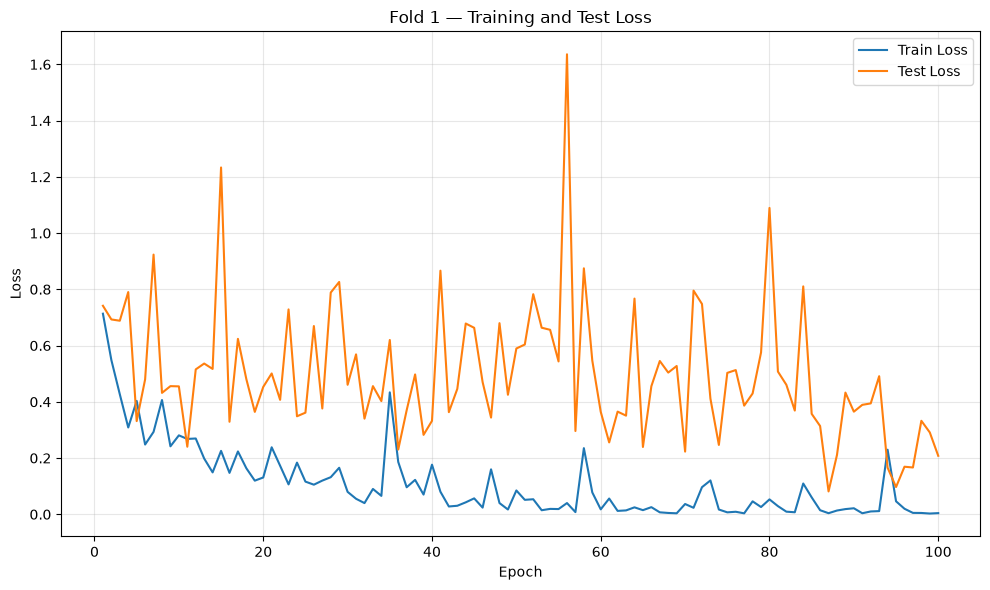

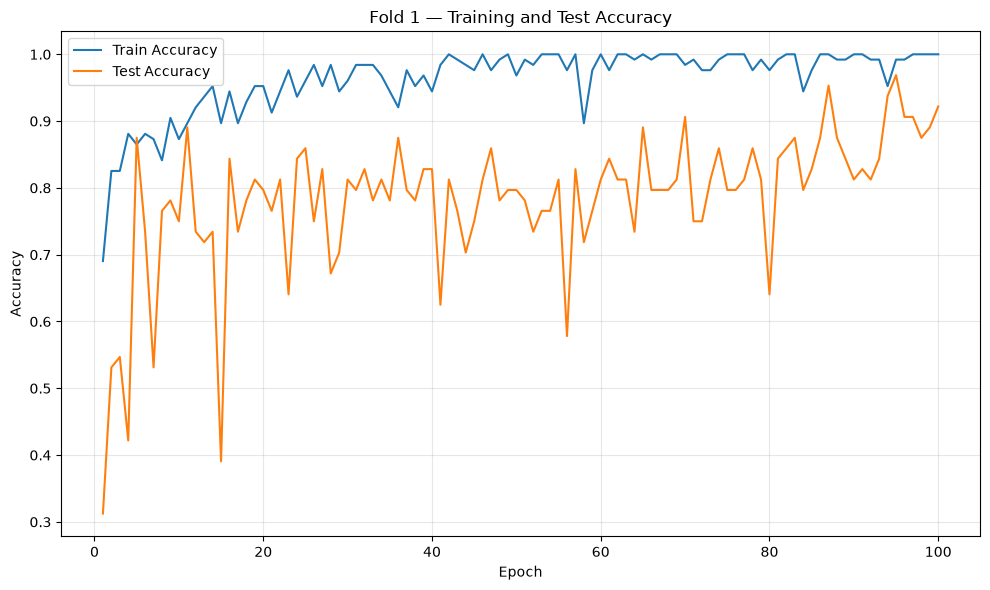

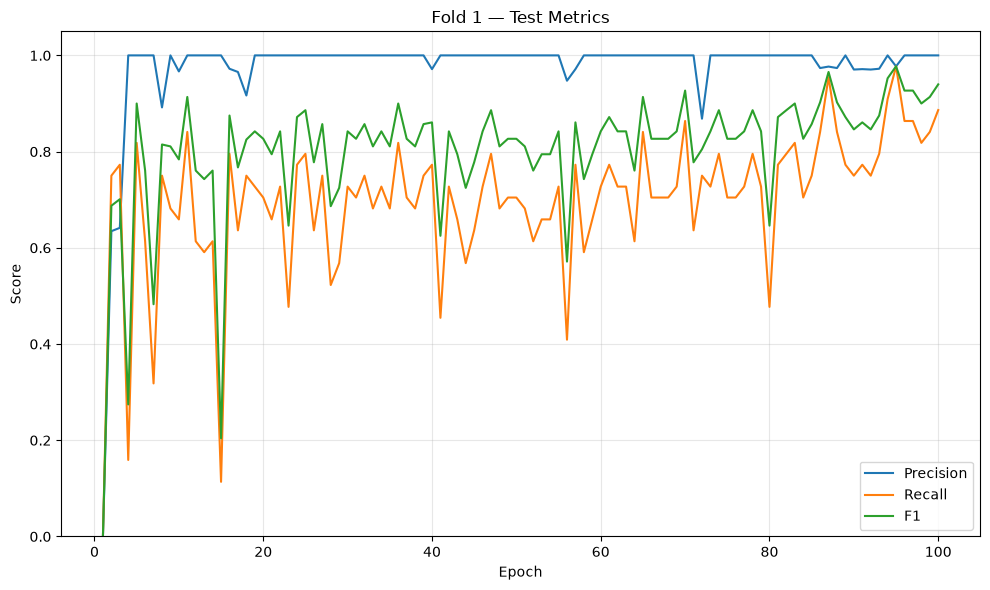

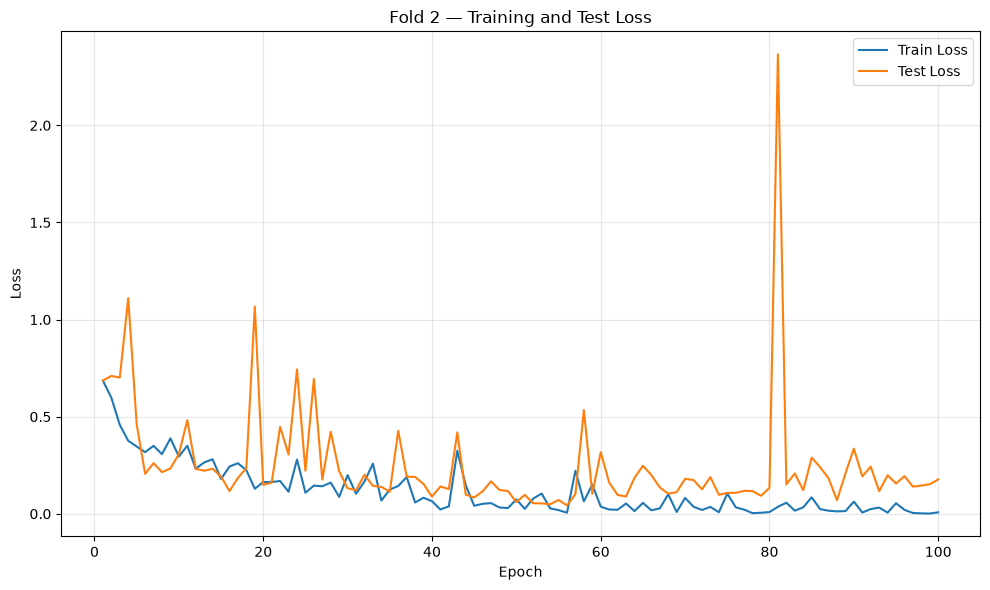

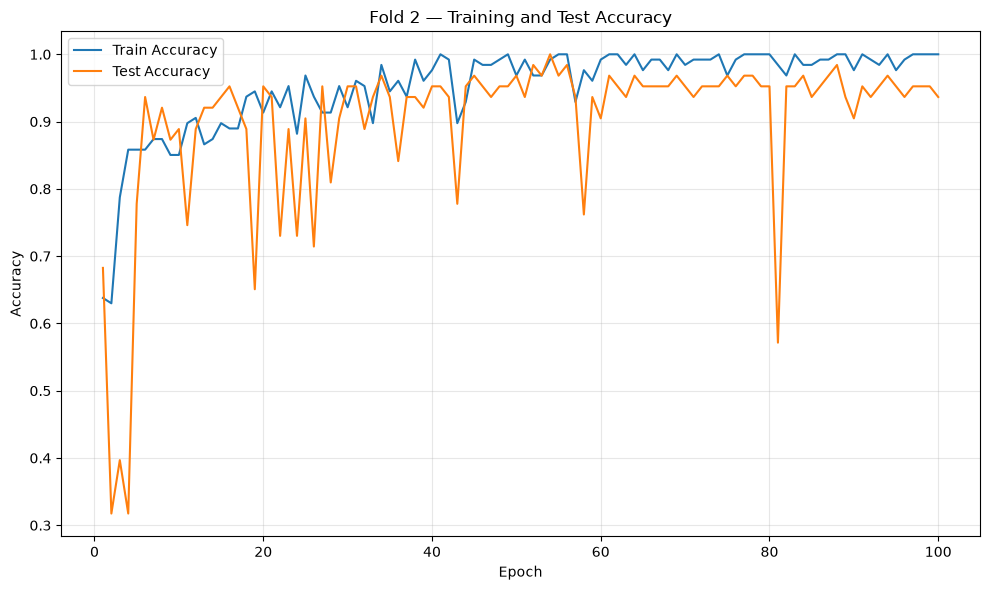

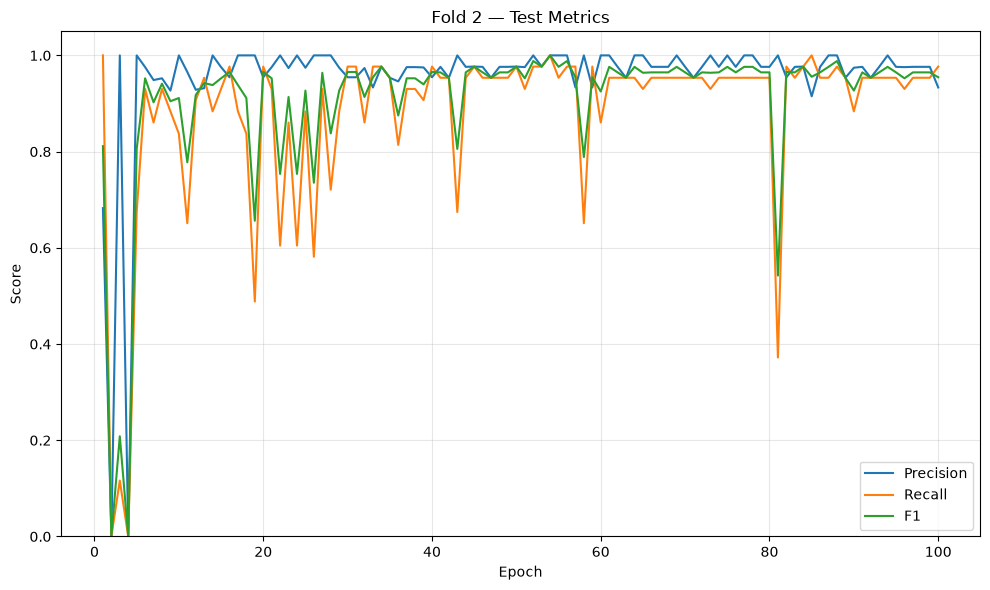

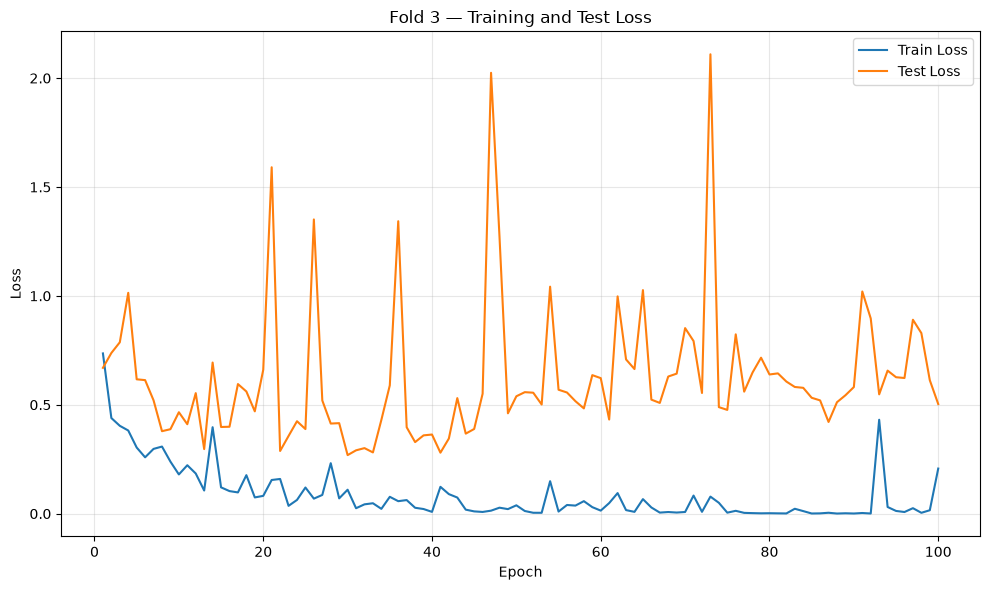

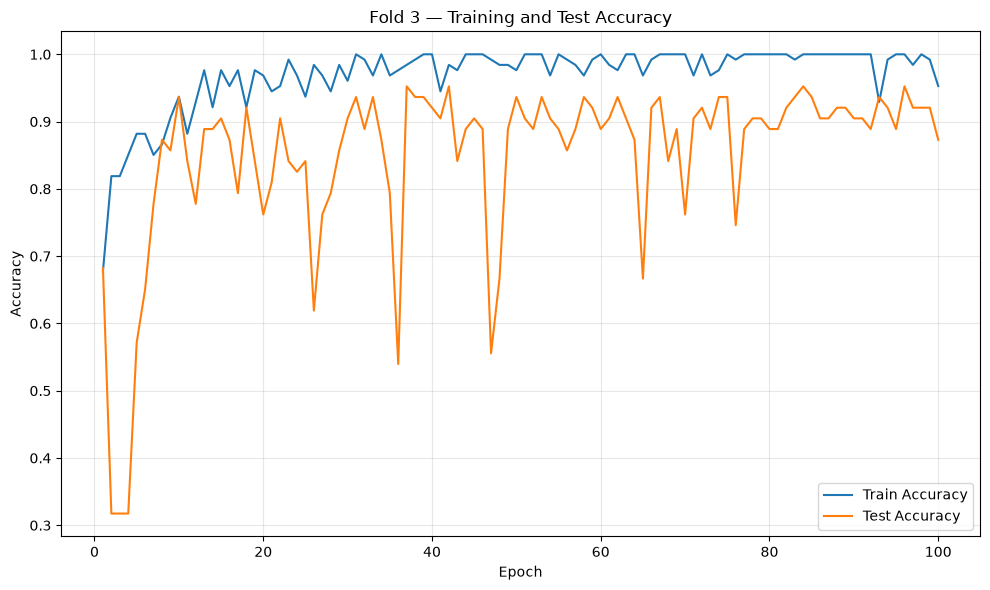

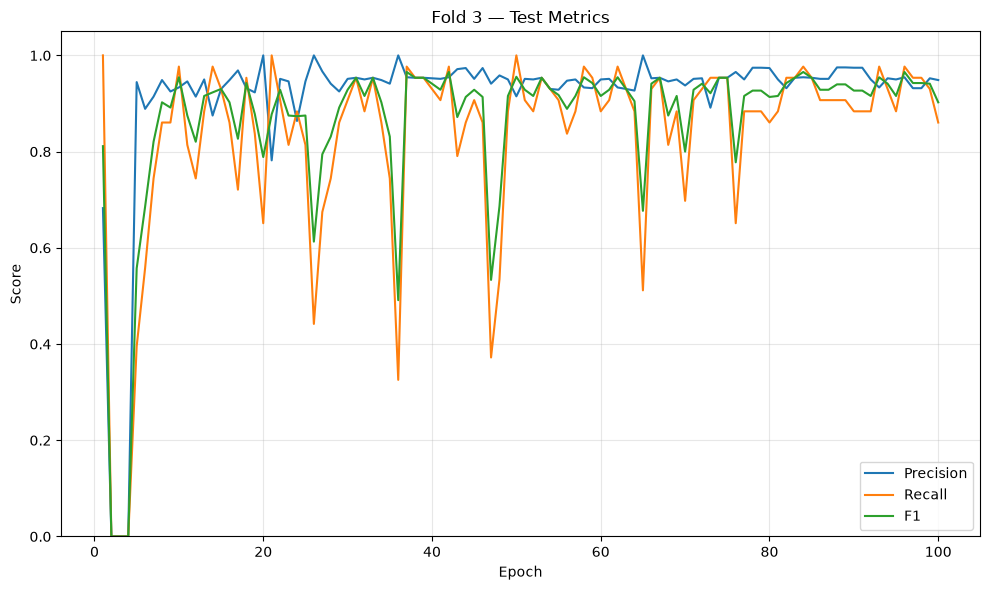


3-FOLD CROSS-VALIDATION RESULTS
Accuracy  : 91.05% ± 3.32%
Precision : 96.07% ± 3.49%
Recall    : 90.79% ± 6.10%
F1        : 93.22% ± 2.69%

Aggregated confusion matrix:
 [[ 55   5]
 [ 12 118]]
TN=55  FP=5  FN=12  TP=118


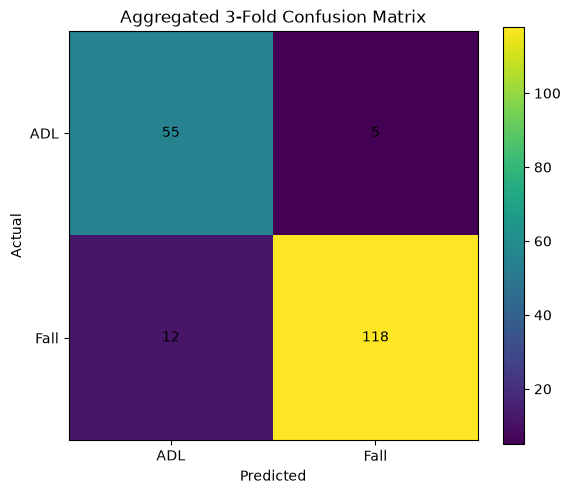


Fold 1 overfitting diagnostic
Final train accuracy : 100.00%
Final test accuracy  : 92.19%
Accuracy gap         : 7.81%
Best test accuracy   : 96.88% (epoch 95)
Final train loss     : 0.0042
Final test loss      : 0.2080

Fold 2 overfitting diagnostic
Final train accuracy : 100.00%
Final test accuracy  : 93.65%
Accuracy gap         : 6.35%
Best test accuracy   : 100.00% (epoch 54)
Final train loss     : 0.0077
Final test loss      : 0.1773

Fold 3 overfitting diagnostic
Final train accuracy : 95.28%
Final test accuracy  : 87.30%
Accuracy gap         : 7.97%
Best test accuracy   : 95.24% (epoch 37)
Final train loss     : 0.2071
Final test loss      : 0.5033


In [26]:
metrics = ["accuracy", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
fold_ids = [r["fold"] for r in fold_results]
values_by_metric = {m: [r["test_metrics"][m] for r in fold_results] for m in metrics}

for result in fold_results:
    fold_id = result["fold"]
    history = result["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_id} — Training and Test Loss")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"fold{fold_id}_loss.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["test_accuracy"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Fold {fold_id} — Training and Test Accuracy")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"fold{fold_id}_accuracy.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["test_precision"], label="Precision")
    plt.plot(epochs, history["test_recall"], label="Recall")
    plt.plot(epochs, history["test_f1"], label="F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.title(f"Fold {fold_id} — Test Metrics")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"fold{fold_id}_test_metrics.png", dpi=150)
    plt.show()

print("\n========================================")
print("3-FOLD CROSS-VALIDATION RESULTS")
print("========================================")
final_summary = {}
for metric, label in zip(metrics, metric_labels):
    values = np.asarray(values_by_metric[metric], dtype=np.float64)
    mean = values.mean()
    std = values.std(ddof=1)
    final_summary[metric] = {"mean": float(mean), "std": float(std), "folds": values.tolist()}
    print(f"{label:10s}: {mean*100:.2f}% ± {std*100:.2f}%")

aggregated_cm = np.sum(
    [np.asarray(r["test_metrics"]["confusion_matrix"], dtype=np.int64) for r in fold_results],
    axis=0,
)
print("\nAggregated confusion matrix:\n", aggregated_cm)
TN, FP, FN, TP = map(int, [aggregated_cm[0,0], aggregated_cm[0,1], aggregated_cm[1,0], aggregated_cm[1,1]])
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")

plt.figure(figsize=(6, 5))
plt.imshow(aggregated_cm, interpolation="nearest")
plt.title("Aggregated 3-Fold Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["ADL", "Fall"])
plt.yticks([0, 1], ["ADL", "Fall"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(aggregated_cm[i, j]), ha="center", va="center")
plt.colorbar(); plt.tight_layout()
plt.savefig(PLOTS_DIR / "aggregated_confusion_matrix.png", dpi=150)
plt.show()

for result in fold_results:
    fold_id = result["fold"]
    history = result["history"]
    train_acc = np.asarray(history["train_accuracy"])
    test_acc = np.asarray(history["test_accuracy"])
    train_loss = np.asarray(history["train_loss"])
    test_loss = np.asarray(history["test_loss"])
    gap = train_acc[-1] - test_acc[-1]
    best_test_epoch = int(np.argmax(test_acc)) + 1
    print(f"\nFold {fold_id} overfitting diagnostic")
    print(f"Final train accuracy : {train_acc[-1]*100:.2f}%")
    print(f"Final test accuracy  : {test_acc[-1]*100:.2f}%")
    print(f"Accuracy gap         : {gap*100:.2f}%")
    print(f"Best test accuracy   : {test_acc.max()*100:.2f}% (epoch {best_test_epoch})")
    print(f"Final train loss     : {train_loss[-1]:.4f}")
    print(f"Final test loss      : {test_loss[-1]:.4f}")

## CELL 25 — SAVE FINAL RESULTS LOCALLY

In [27]:
results = {
    "model": "GSTCAN",
    "pose_estimator": "RTMPose-X / rtmlib",
    "dataset": "Local video + same-name TXT labels",
    "video_dir": str(VIDEO_DIR.resolve()),
    "label_dir": str(LABEL_DIR.resolve()),
    "results_dir": str(RESULTS_DIR.resolve()),
    "full_sequence": True,
    "temporal_windows": False,
    "num_joints": 13,
    "joint_names": JOINT_NAMES,
    "root_node": ROOT_NODE,
    "spatial_partitions": ["root", "centripetal", "centrifugal"],
    "gstcan_channels": [64, 64, 128, 128, 256, 256],
    "temporal_kernel": 9,
    "dropout": DROPOUT,
    "optimizer": "RMSprop",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": FINAL_EPOCHS,
    "cross_validation": "3-fold sequence-level",
    "pose_conf_threshold": POSE_CONF_THRESHOLD,
    "sequence_count": len(records),
    "fall_sequences": sum(r["label"] == 1 for r in records),
    "adl_sequences": sum(r["label"] == 0 for r in records),
    "summary": final_summary,
    "fold_results": fold_results,
    "aggregated_confusion_matrix": aggregated_cm.tolist(),
    "TN": TN,
    "FP": FP,
    "FN": FN,
    "TP": TP,
}

results_file = METRICS_DIR / "gstcan_rtmpose_x_local_results.json"
with open(results_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

# Also save the deterministic split for reproducibility.
with open(METRICS_DIR / "folds.json", "w", encoding="utf-8") as f:
    json.dump(folds, f, indent=2)

print("Saved results:", results_file)
print("Saved folds  :", METRICS_DIR / "folds.json")
print("All generated files are under:", RESULTS_DIR)

Saved results: D:\Le2i\Results\RTM-PoseX Results\metrics\gstcan_rtmpose_x_local_results.json
Saved folds  : D:\Le2i\Results\RTM-PoseX Results\metrics\folds.json
All generated files are under: D:\Le2i\Results\RTM-PoseX Results


## CELL 26 — LEAKAGE / CONSISTENCY AUDIT

In [28]:
import hashlib

processed_files = sorted(PROCESSED_DIR.glob("*.pkl"))
sequence_names_processed = []
path_to_sequence = {}
duplicate_paths = []
sequence_hashes = {}
duplicate_sequences = []

for file_path in processed_files:
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    sequence = data["sequence"]
    sequence_names_processed.append(sequence)

    # Every processed checkpoint refers to exactly one input video.
    assert Path(data["video_path"]).exists(), f"Missing source video: {data['video_path']}"
    assert Path(data["label_file"]).exists(), f"Missing label file: {data['label_file']}"
    assert int(data["label"]) in {0, 1}

    # Check frame indices are unique and ordered.
    frame_indices = list(data["kept_frame_indices"])
    assert frame_indices == sorted(set(frame_indices))

    # Verify paths cannot overlap because videos are the source sequences.
    source_path = str(Path(data["video_path"]).resolve())
    if source_path in path_to_sequence and path_to_sequence[source_path] != sequence:
        duplicate_paths.append((source_path, path_to_sequence[source_path], sequence))
    else:
        path_to_sequence[source_path] = sequence

    motion = np.asarray(data["motion"], dtype=np.float32)
    digest = hashlib.sha256(motion.tobytes()).hexdigest()
    if digest in sequence_hashes:
        duplicate_sequences.append((sequence_hashes[digest], sequence))
    else:
        sequence_hashes[digest] = sequence

assert len(sequence_names_processed) == len(records)
assert len(set(sequence_names_processed)) == len(records)
assert not duplicate_paths, duplicate_paths

# Fold leakage checks.
all_test = []
for fold in folds:
    train_set = set(fold["train_sequences"])
    test_set = set(fold["test_sequences"])
    assert not (train_set & test_set), f"Fold {fold['fold']} has train/test overlap."
    all_test.extend(fold["test_sequences"])

assert len(all_test) == len(records)
assert len(set(all_test)) == len(records)

# Each sequence must be tested exactly once.
test_counts = {name: 0 for name in sequence_names_processed}
for fold in folds:
    for name in fold["test_sequences"]:
        test_counts[name] += 1
assert all(count == 1 for count in test_counts.values())

print("TEST 1 PASSED — unique processed sequence IDs")
print("TEST 2 PASSED — no train/test overlap inside any fold")
print("TEST 3 PASSED — every sequence is test exactly once")
print("TEST 4 PASSED — no source video belongs to multiple sequences")
print("Exact duplicate feature sequences found:", len(duplicate_sequences))
for item in duplicate_sequences:
    print("  ", item)

print("\n========================================")
print("LEAKAGE / CONSISTENCY AUDIT COMPLETE")
print("========================================")

TEST 1 PASSED — unique processed sequence IDs
TEST 2 PASSED — no train/test overlap inside any fold
TEST 3 PASSED — every sequence is test exactly once
TEST 4 PASSED — no source video belongs to multiple sequences
Exact duplicate feature sequences found: 3
   ('video (119)', 'video (120)')
   ('video (84)', 'video (85)')
   ('video (83)', 'video (94)')

LEAKAGE / CONSISTENCY AUDIT COMPLETE
